In [ ]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [ ]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

In [94]:
scan_type = 'nifti'

scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_CEUS.nii'
scan_loader_kwargs = {
    'transpose': False,
}

In [95]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, scan_path, **scan_loader_kwargs)

In [32]:
image_data.pixel_data.shape

(295, 218, 219, 530)

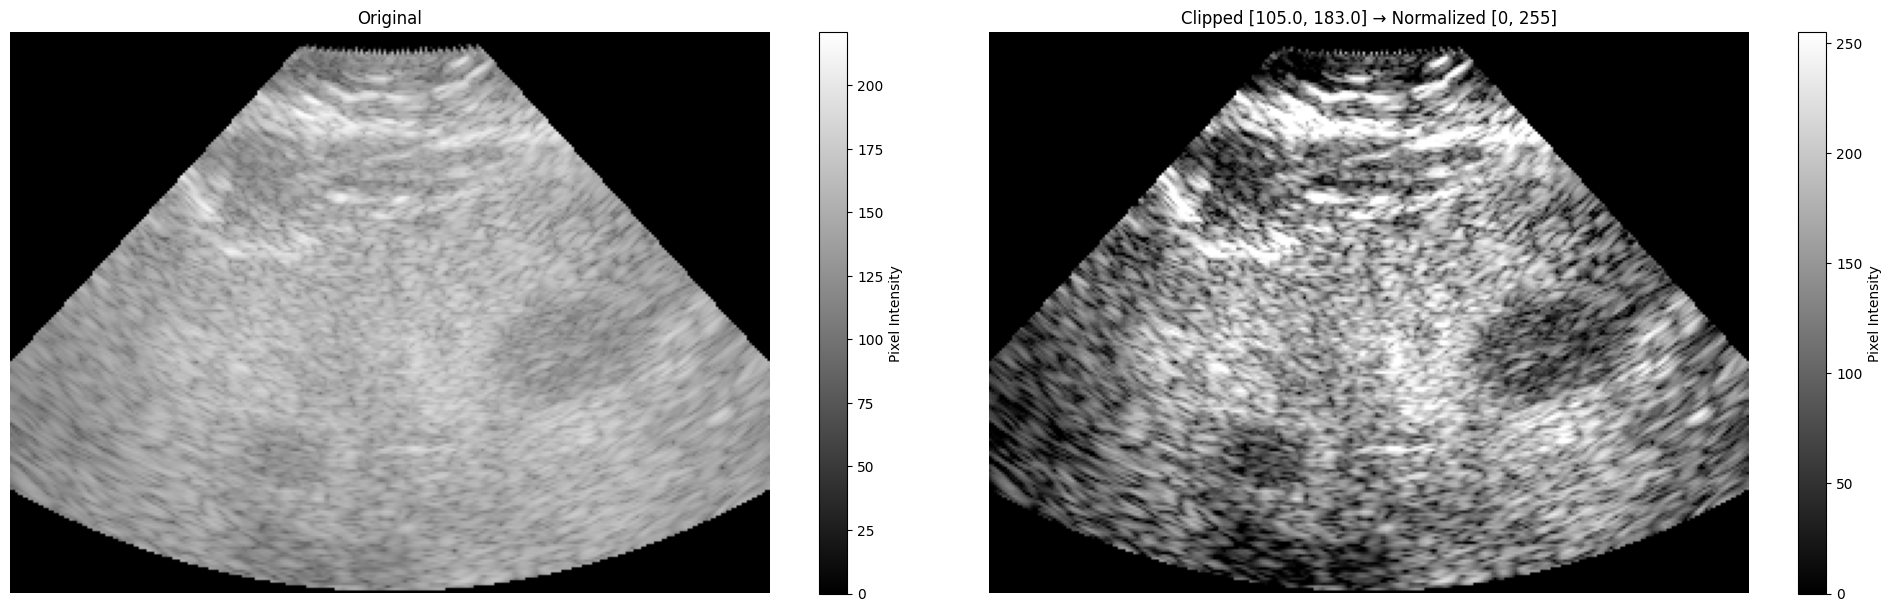

In [92]:
import numpy as np
import matplotlib.pyplot as plt

axial_slice = image_data.pixel_data[:, :, 100, 0]

# Mask out zeros before computing percentiles
non_zero = axial_slice[axial_slice != 0]

# Compute 10th and 90th percentile on non-zero values
p_low = np.percentile(non_zero, 2)
p_high = np.percentile(non_zero, 98)

# Clip and normalize to 0-255
clipped_slice = np.clip(axial_slice, p_low, p_high)
normalized_slice = ((clipped_slice - p_low) / (p_high - p_low) * 255).astype(np.uint8)

# Display all three side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].imshow(axial_slice.T, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0], label='Pixel Intensity')

axes[1].imshow(normalized_slice.T, cmap='gray')
axes[1].set_title(f'Clipped [{p_low:.1f}, {p_high:.1f}] → Normalized [0, 255]')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1], label='Pixel Intensity')

plt.tight_layout()
plt.show()

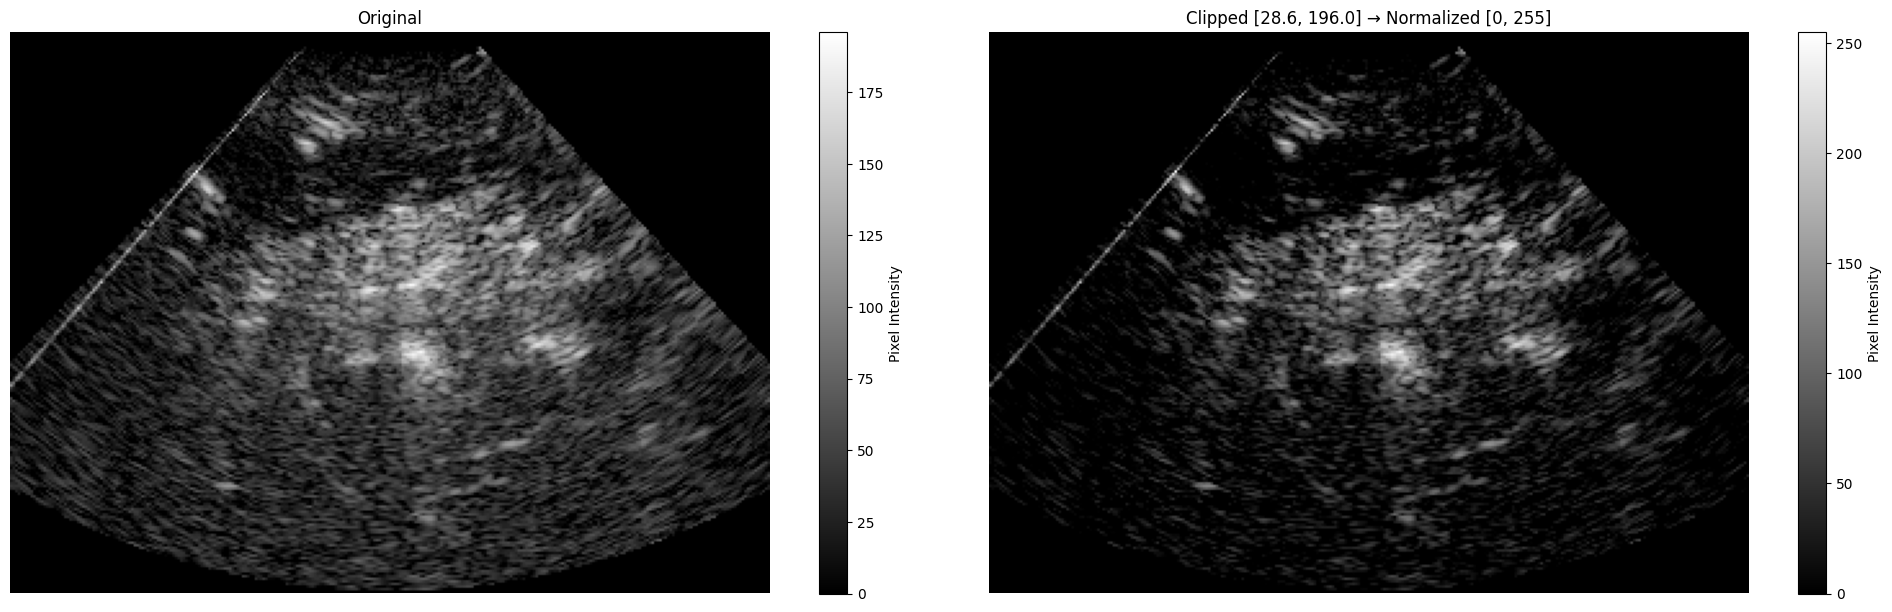

In [96]:
## CEUS

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

ref_slice = image_data.pixel_data[:, :, 100, 0]
axial_slice = image_data.pixel_data[:, :, 100, 50]

# Mask out zeros before computing percentiles
non_zero = axial_slice[axial_slice != 0]
non_zero_ref = ref_slice[ref_slice != 0]

# Compute 2nd and 98th percentile on non-zero values
p_low = np.mean(non_zero_ref)
p_high = np.percentile(non_zero, 100)

# Clip and normalize to 0-255
clipped_slice = np.clip(axial_slice, p_low, p_high)
normalized_slice = ((clipped_slice - p_low) / (p_high - p_low) * 255).astype(np.uint8)

# Apply median pooling kernel
kernel_size = 5  # adjust as needed
median_slice = median_filter(normalized_slice, size=kernel_size)

# Display all three side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].imshow(axial_slice.T, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0], label='Pixel Intensity')

axes[1].imshow(normalized_slice.T, cmap='gray')
axes[1].set_title(f'Clipped [{p_low:.1f}, {p_high:.1f}] → Normalized [0, 255]')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1], label='Pixel Intensity')

plt.tight_layout()
plt.show()

## Image Preprocessing

In [ ]:
from src.image_preprocessing.options import get_im_preproc_funcs, get_required_im_preproc_kwargs

print("Available preprocessing functions:", list(get_im_preproc_funcs().keys()))

In [ ]:
preproc_func_names = ['resample'] # in order of application
required_kwargs = get_required_im_preproc_kwargs(preproc_func_names)
print("Required kwargs for preprocessing functions:", required_kwargs)

In [ ]:
preproc_kwargs = {
    'target_vox_size': (1.0, 1.0, 1.0),
    'interp': 'linear',
}

In [ ]:
from src.entrypoints import scan_preprocessing_step

image_data = scan_preprocessing_step(preproc_func_names, image_data, **preproc_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [ ]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

In [ ]:
seg_type = 'nifti'

seg_path = '/media/das/TOSHIBA EXT/P-Selectin Data/July VOIs (Ashley)/20190725103303.756_segmentation_LEFT.nii.gz'
seg_loader_kwargs = {}

In [ ]:
from src.entrypoints import seg_loading_step

seg_data = seg_loading_step(seg_type, image_data, seg_path, scan_path, **seg_loader_kwargs)

## Segmentation Preprocessing

In [ ]:
from src.seg_preprocessing.options import get_seg_preproc_funcs, get_required_seg_preproc_kwargs

print("Available preprocessing functions:", list(get_seg_preproc_funcs().keys()))

In [ ]:
preproc_func_names = ['resample'] # in order of application
required_kwargs = get_required_seg_preproc_kwargs(preproc_func_names)
print("Required kwargs for preprocessing functions:", required_kwargs)

In [ ]:
preproc_kwargs = {
    'target_vox_size': (1.0, 1.0, 1.0),
    'interp': 'nearest',
}

In [ ]:
from src.entrypoints import seg_preprocessing_step

seg_data = seg_preprocessing_step(preproc_func_names, image_data, seg_data, **preproc_kwargs)

## CEUS Quantitative Temporal Curve Analysis

In [ ]:
from src.time_series_analysis.options import get_analysis_types, get_required_kwargs

all_analysis_types, all_analysis_funcs = get_analysis_types()
print("Available analysis types:", list(all_analysis_types.keys()))

In [ ]:
analysis_type = 'curves'

print("Available analysis functions:", list(all_analysis_funcs.keys()))

In [ ]:
analysis_funcs = ['tic']

# Find all required kwargs for the analysis functions
analysis_funcs = analysis_funcs if len(analysis_funcs) else list(all_analysis_funcs[analysis_type].keys())
required_kwargs = get_required_kwargs(analysis_type, analysis_funcs)
print("Required kwargs for current analysis:", required_kwargs)

In [ ]:
analysis_kwargs = {
    'curves_output_path': 'sample.csv',
}

In [ ]:
from src.entrypoints import analysis_step

analysis_obj = analysis_step(analysis_type, image_data, seg_data, analysis_funcs, **analysis_kwargs)

## Curve Quantification

In [ ]:
from src.curve_quantification.options import get_quantification_funcs

quantification_funcs = get_quantification_funcs()
print("Available quantification functions:", quantification_funcs.keys())

In [ ]:
function_names = ['dte'] # Empty list will use all functions
output_path = 'test_quants.csv'
curve_quantifications_kwargs = {
    'curves_to_fit': ['moderate-pselectin_diagnostics_Image-original_Mean'],
    'n_frames_to_analyze': 100,
    'tic_name': 'TIC'
}

In [ ]:
from src.entrypoints import curve_quantification_step

curve_quant = curve_quantification_step(analysis_obj, function_names, output_path, **curve_quantifications_kwargs)